#**Load Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.stats as stats
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from scipy.stats import skew, kurtosis

pd.set_option('display.float_format', '{:.2f}'.format)

# **Load dataset**

In [ ]:
!pip install -U gdown

import gdown

file_id = '1ZoF9WtJdwVnrEI2AZFAhCaKdOMcasNWf'
gdown.download(f'https://drive.google.com/uc?id={file_id}', 'airline financials.csv', quiet=False)

df = pd.read_csv('airline financials.csv', encoding='utf-8')
df.head()

Downloading...
From: https://drive.google.com/uc?id=1ZoF9WtJdwVnrEI2AZFAhCaKdOMcasNWf
To: /content/airline financials.csv
100%|██████████| 11.0k/11.0k [00:00<00:00, 21.2MB/s]


,Year,Revenue,EBIT,Old TaxRate,Tax Rates,InvestedCapital,Old ROIC,ROIC,Net Income,Total Assets,Total Debt,CapEx,Depreciation,Company
0,2012,2470200.00,13300.00,0.28,0.28,1208600.00,0.01,0.007869862,11500.00,2241700.00,1456200.00,-53300.00,130700.00,Finnair
1,2013,2419100.00,11900.00,0.15,0.15,1088800.00,0.01,0.009338982,22600.00,2117600.00,1439600.00,-96400.00,140700.00,Finnair
2,2014,2302800.00,-36500.00,0.17,0.00,805100.00,-0.04,-0.045335983,-82700.00,1885100.00,1370800.00,-142100.00,135700.00,Finnair
3,2015,2461200.00,100500.00,0.21,0.21,128900.00,0.62,0.617270721,89400.00,2050300.00,1559000.00,-352500.00,148500.00,Finnair
4,2016,2392300.00,55200.00,0.20,0.20,1483200.00,0.03,0.029935275,85100.00,2528700.00,1671700.00,-475700.00,102900.00,Finnair


# **Descriptive Statistics**

In [ ]:
# Decomposing

df['OperatingMargin'] = df['EBIT'] / df['Revenue']
df['CapitalTurnover'] = df['Revenue'] / df['InvestedCapital']
df['NOPATMargin'] = df['EBIT'] * (1 - df['Tax Rates']) / df['Revenue']

df['ROIC_decomposed'] = df['NOPATMargin'] * df['CapitalTurnover']

In [ ]:
# Convert 'Year' to datetime and 'ROIC' to numeric
df['Year'] = pd.to_datetime(df['Year'].astype(str) + '-12-31')
df['ROIC'] = pd.to_numeric(df['ROIC'], errors='coerce')
df.dtypes

,0
Year,datetime64[ns]
Revenue,float64
EBIT,float64
Old TaxRate,float64
Tax Rates,float64
InvestedCapital,float64
Old ROIC,float64
ROIC,float64
Net Income,float64
Total Assets,float64


In [ ]:
df.describe()

,Year,Revenue,EBIT,Old TaxRate,Tax Rates,InvestedCapital,Old ROIC,ROIC,Net Income,Total Assets,Total Debt,CapEx,Depreciation,OperatingMargin,CapitalTurnover,NOPATMargin,ROIC_decomposed
count,91,91.00,91.00,43.00,91.00,91.00,91.00,90.00,91.00,91.00,91.00,86.00,91.00,91.00,91.00,91.00,91.00
mean,2018-12-31 03:41:32.307692288,10150578.88,267095.73,0.21,0.22,3816048.23,0.70,0.61,46450.10,12892005.60,10926794.42,-1050361.01,855063.63,-0.01,inf,-0.02,inf
min,2012-12-31 00:00:00,418195.00,-7129000.00,0.12,0.00,-178348.33,-3.97,-3.12,-7100000.00,353354.00,243944.00,-4097000.00,11822.00,-1.01,-34.00,-1.01,-3.12
25%,2015-12-31 00:00:00,1676750.00,-3254.87,0.16,0.00,450716.63,-0.02,-0.05,-2795.50,2129850.00,1558104.81,-1843025.00,132020.34,-0.00,1.36,-0.01,-0.05
50%,2018-12-31 00:00:00,3105600.00,158800.69,0.21,0.10,2563600.00,0.14,0.12,108004.00,4722600.00,4207110.86,-439950.00,336000.00,0.05,2.28,0.04,0.12
75%,2021-12-31 00:00:00,16117000.00,988000.00,0.28,0.21,5762061.37,0.26,0.27,471400.00,24379000.00,23072500.00,-89179.81,1686500.00,0.10,4.56,0.08,0.28
max,2024-12-31 00:00:00,38387000.00,3064000.00,0.30,8.86,16332000.00,15.37,14.15,2340000.00,47052000.00,38097000.00,-610.64,4552000.00,0.23,inf,0.21,inf
std,NaN,12331564.59,1331218.79,0.06,0.93,4083950.67,2.61,2.32,1358605.58,13993390.90,12472911.00,1191745.38,1010960.93,0.22,NaN,0.22,NaN


- Bimodal performance: A few high-revenue, high-ROIC firms dominate, while others struggle (negative EBIT/Net Income).

- High leverage: Debt levels are nearly as high as total assets, risking solvency for some.

- Tax/Data anomalies: Investigate outliers in tax rates and negative invested capital.

- Investment patterns: Large CapEx variances suggest divergent growth strategies (aggressive vs. conservative).

=> Next step:
(1) Examine time-series performance of companies
(2) Segment the dataset into "high-performers" vs. "developing" companies and check their descriptive statistics

# **Compare performance across time and firms**

## **Time Series Analysis**

### Revenue
- There is a drop/stagnant growth happening from 2020 - 2021 (possibly due to Covid).
- Especially for Lufthansa & Air France that experienced a dramatic decrease in this period.
- However, these 2 companies also made a drastic recovery from 2022 and reaching their peaks in 2024.
- On the other hand, Finnair demonstrated a relatively stable revenue trend with only a slight decrease in 2020 - 2021.

### ROIC
- ROIC trend is very fluctuated, especially for Aegean Airlines, Wizz Air, and Norwegian.
- Other companies' trends remain stable (including Finnair)

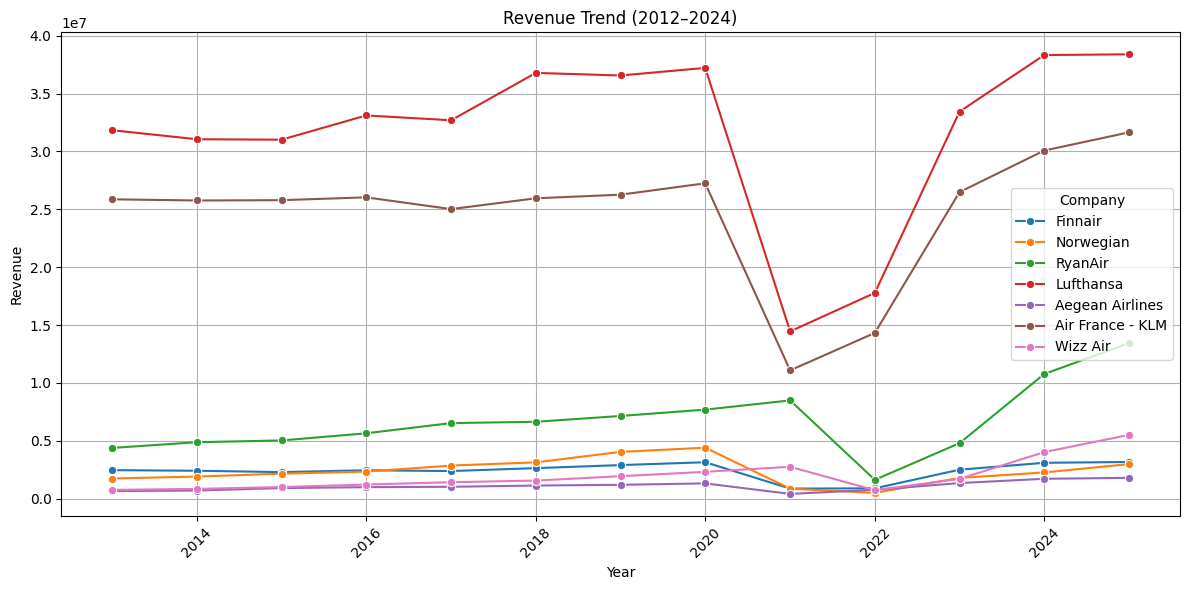

Revenue                                                 \
                   count        mean        std         min         25%   
Company                                                                   
Aegean Airlines    13.00  1082960.62  405873.23   418195.00   774094.00   
Air France - KLM   13.00 24734230.77 5696087.90 11088000.00 25761000.00   
Finnair            13.00  2409569.23  740665.58   877600.00  2392300.00   
Lufthansa          13.00 31740384.62 7452250.29 14454000.00 31052000.00   
Norwegian          13.00  2391287.91 1114604.82   507310.90  1794227.52   
RyanAir            13.00  6703646.15 3003907.72  1635800.00  4884000.00   
Wizz Air           13.00  1991972.85 1407372.11   739000.00  1011816.00   

                                                      
                         50%         75%         max  
Company                                               
Aegean Airlines   1034538.00  1328121.00  1805440.00  
Air France - KLM 25952000.00 26487000.00 31649000.00  
Finnair           2470200.00  2908300.00  3176800.00  
Lufthansa        33107000.00 36781000.00 38387000.00  
Norwegian         2272613.45  2995104.04  4412441.52  
RyanAir           6535800.00  7697400.00 13443800.00  
Wizz Air          1571200.00  2326700.00  5516500.00

In [ ]:
# Revenue over time for each company

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year', y='Revenue', hue='Company', marker='o')
plt.title("Revenue Trend (2012–2024)")
plt.ylabel("Revenue")
plt.xlabel("Year")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

df.groupby('Company')[['Revenue']].describe()

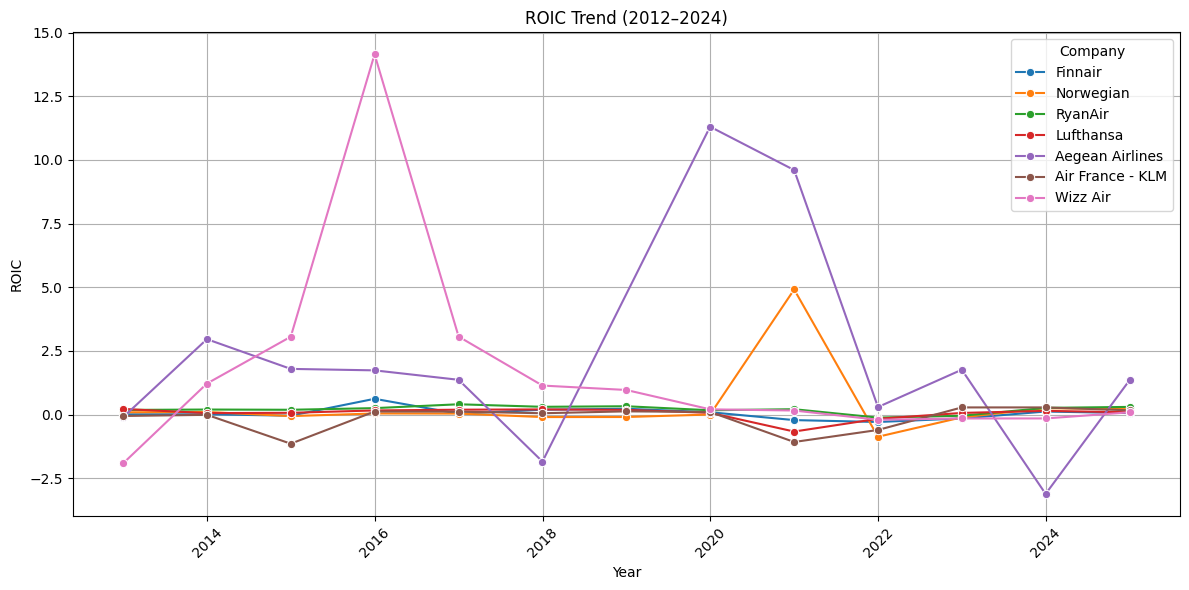

ROIC                                       
                 count  mean  std   min   25%  50%  75%   max
Company                                                      
Aegean Airlines  12.00  2.26 4.20 -3.12  0.19 1.55 2.08 11.30
Air France - KLM 13.00 -0.13 0.49 -1.15 -0.06 0.10 0.12  0.28
Finnair          13.00  0.05 0.23 -0.29 -0.05 0.03 0.12  0.62
Lufthansa        13.00  0.05 0.24 -0.67  0.06 0.09 0.18  0.22
Norwegian        13.00  0.34 1.40 -0.87 -0.10 0.04 0.10  4.91
RyanAir          13.00  0.20 0.14 -0.12  0.18 0.21 0.30  0.40
Wizz Air         13.00  1.66 3.99 -1.92 -0.15 0.20 1.22 14.15

In [ ]:
# ROIC over time for each company

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year', y='ROIC', hue='Company', marker='o')
plt.title("ROIC Trend (2012–2024)")
plt.ylabel("ROIC")
plt.xlabel("Year")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

df.groupby('Company')[['ROIC']].describe()

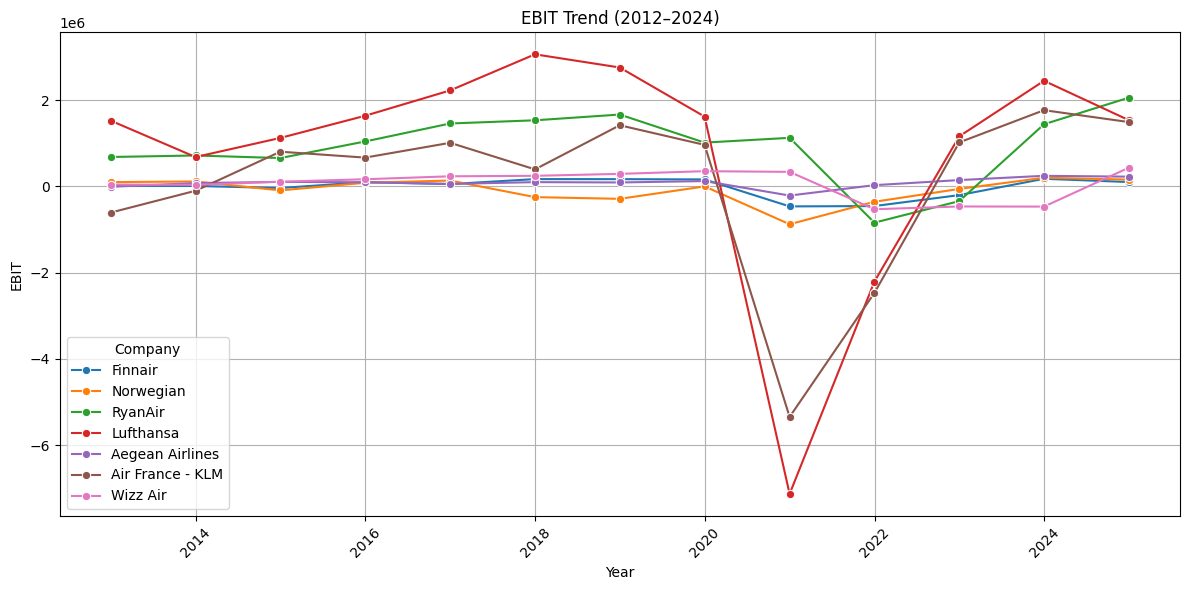

EBIT                                                         \
                 count      mean        std         min        25%        50%   
Company                                                                         
Aegean Airlines  13.00  83935.46  112810.25  -210963.00   58854.00   97203.00   
Air France - KLM 13.00  79230.77 1969853.39 -5344000.00 -100000.00  806000.00   
Finnair          13.00 -14630.77  223427.66  -462500.00  -36500.00   55200.00   
Lufthansa        13.00 804000.00 2712869.08 -7129000.00 1125000.00 1534000.00   
Norwegian        13.00 -85694.30  298408.90  -875844.30 -247231.50    1044.26   
RyanAir          13.00 940984.62  801583.92  -839400.00  683200.00 1042900.00   
Wizz Air         13.00  61844.31  334025.02  -528100.00   37990.00  167300.00   

                                        
                        75%        max  
Company                                 
Aegean Airlines   124813.00  246828.00  
Air France - KLM 1021000.00 1769000.00  
Finnair           162900.00  178000.00  
Lufthansa        2227000.00 3064000.00  
Norwegian         115642.97  201737.79  
RyanAir          1460100.00 2060700.00  
Wizz Air          291900.00  437200.00

In [ ]:
# EBIT over time for each company
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year', y='EBIT', hue='Company', marker='o')
plt.title("EBIT Trend (2012–2024)")
plt.ylabel("EBIT")
plt.xlabel("Year")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

df.groupby('Company')[['EBIT']].describe()

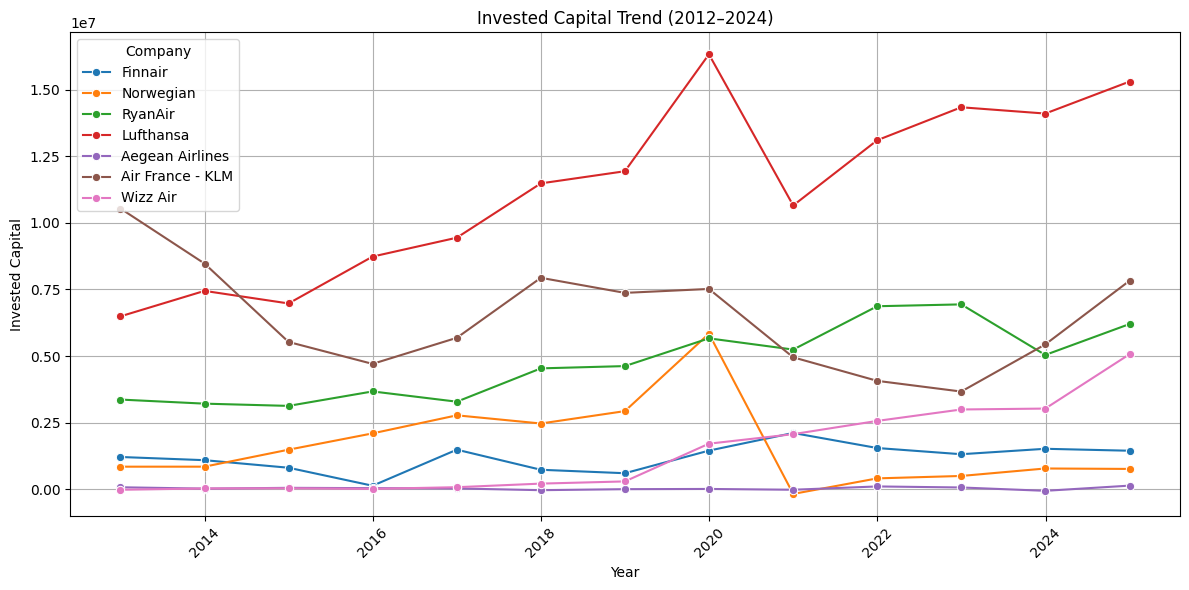

InvestedCapital                                               \
                           count        mean        std        min        25%   
Company                                                                         
Aegean Airlines            13.00    30135.23   55145.92  -62131.00       0.00   
Air France - KLM           13.00  6439461.54 2002118.32 3666000.00 4952000.00   
Finnair                    13.00  1186069.23  513099.32  128900.00  805100.00   
Lufthansa                  13.00 11259153.85 3282778.52 6491000.00 8735000.00   
Norwegian                  13.00  1656768.72 1592162.89 -178348.33  760267.33   
RyanAir                    13.00  4752392.31 1379960.99 3127700.00 3365300.00   
Wizz Air                   13.00  1388356.77 1649391.54  -22530.00   33045.00   

                                                      
                         50%         75%         max  
Company                                               
Aegean Airlines     26947.00    63440.00   132944.00  
Air France - KLM  5685000.00  7827000.00 10540000.00  
Finnair           1312600.00  1483200.00  2110700.00  
Lufthansa        11485000.00 14107000.00 16332000.00  
Norwegian          844933.00  2466257.44  5839122.74  
RyanAir           4622400.00  5664400.00  6940000.00  
Wizz Air           291100.00  2563600.00  5068400.00

In [ ]:
# Invested Capital over time for each company
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year', y='InvestedCapital', hue='Company', marker='o')
plt.title("Invested Capital Trend (2012–2024)")
plt.ylabel("Invested Capital")
plt.xlabel("Year")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

df.groupby('Company')[['InvestedCapital']].describe()

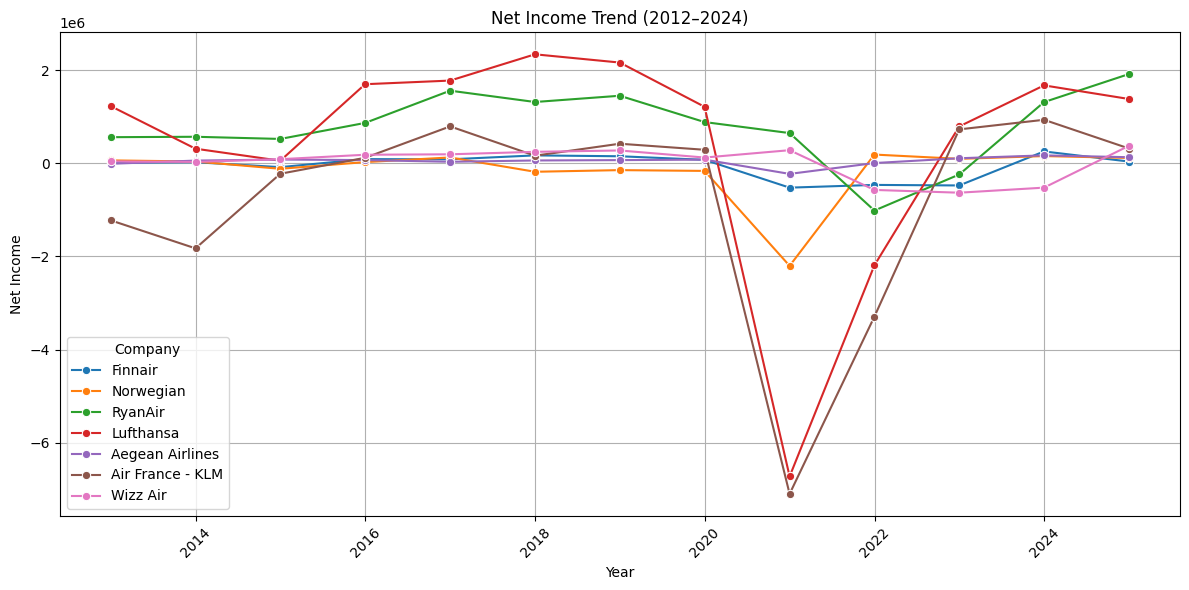

Net Income                                                \
                      count       mean        std         min         25%   
Company                                                                     
Aegean Airlines       13.00   47695.31   95694.07  -227907.00    32210.00   
Air France - KLM      13.00 -762076.92 2254950.72 -7100000.00 -1225000.00   
Finnair               13.00  -50146.15  262852.96  -523200.00   -82700.00   
Lufthansa             13.00  439538.46 2451453.47 -6725000.00   313000.00   
Norwegian             13.00 -154634.62  628321.09 -2202212.06  -146843.41   
RyanAir               13.00  796392.31  784047.62 -1015100.00   560400.00   
Wizz Air              13.00    8382.31  347881.48  -631800.00    29258.00   

                                                   
                        50%        75%        max  
Company                                            
Aegean Airlines    67918.00   80441.00  169967.00  
Air France - KLM  163000.00  420000.00  934000.00  
Finnair            37000.00   89400.00  254300.00  
Lufthansa        1228000.00 1698000.00 2340000.00  
Norwegian          38350.24  114921.67  187245.95  
RyanAir           866700.00 1315900.00 1917100.00  
Wizz Air          123000.00  246000.00  376600.00

In [ ]:
# Net income over time for each company
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year', y='Net Income', hue='Company', marker='o')
plt.title("Net Income Trend (2012–2024)")
plt.ylabel("Net Income")
plt.xlabel("Year")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

df.groupby('Company')[['Net Income']].describe()

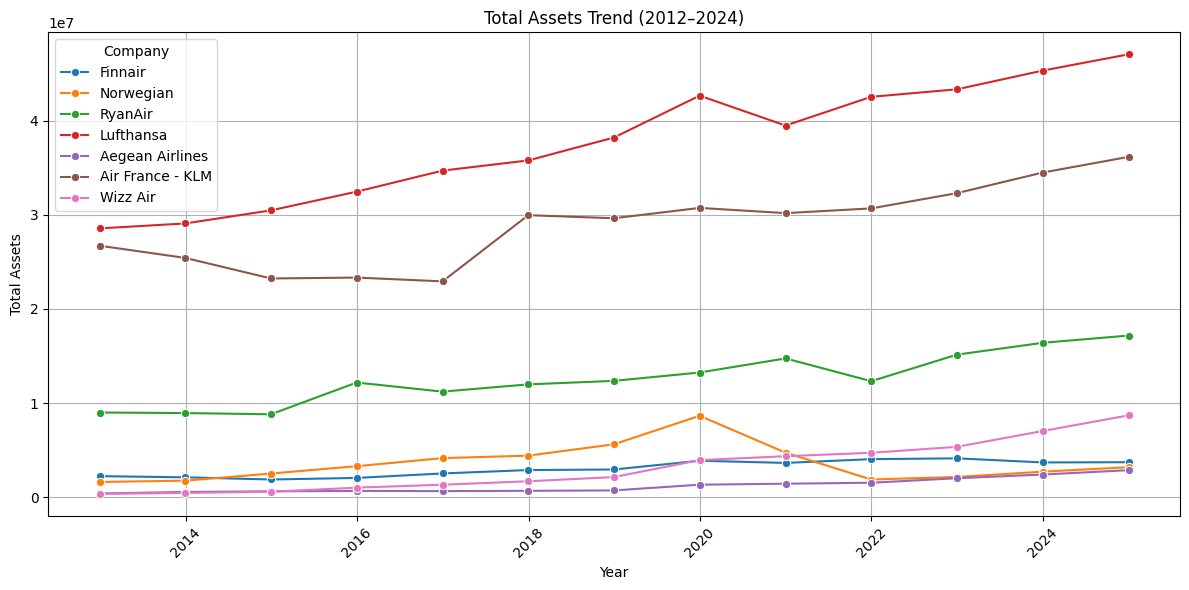

Total Assets                                                 \
                        count        mean        std         min         25%   
Company                                                                        
Aegean Airlines         13.00  1225799.46  794975.26   397158.00   650761.00   
Air France - KLM        13.00 28907692.31 4289417.72 22932000.00 25423000.00   
Finnair                 13.00  3060100.00  829914.41  1885100.00  2241700.00   
Lufthansa               13.00 37665846.15 6317162.51 28559000.00 32462000.00   
Norwegian               13.00  3594969.59 1967188.17  1621848.46  2155587.13   
RyanAir                 13.00 12582192.31 2741821.78  8812100.00 11218300.00   
Wizz Air                13.00  3207439.38 2705607.38   353354.00  1020500.00   

                                                      
                         50%         75%         max  
Company                                               
Aegean Airlines    725907.00  1540411.00  2874408.00  
Air France - KLM 29963000.00 30735000.00 36155000.00  
Finnair           2947300.00  3721000.00  4133000.00  
Lufthansa        38213000.00 42659000.00 47052000.00  
Norwegian         3188743.35  4420228.05  8652438.33  
RyanAir          12328000.00 14747200.00 17175600.00  
Wizz Air          2142100.00  4722600.00  8694900.00

In [ ]:
# Total Assets over time for each company
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year', y='Total Assets', hue='Company', marker='o')
plt.title("Total Assets Trend (2012–2024)")
plt.ylabel("Total Assets")
plt.xlabel("Year")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

df.groupby('Company')[['Total Assets']].describe()

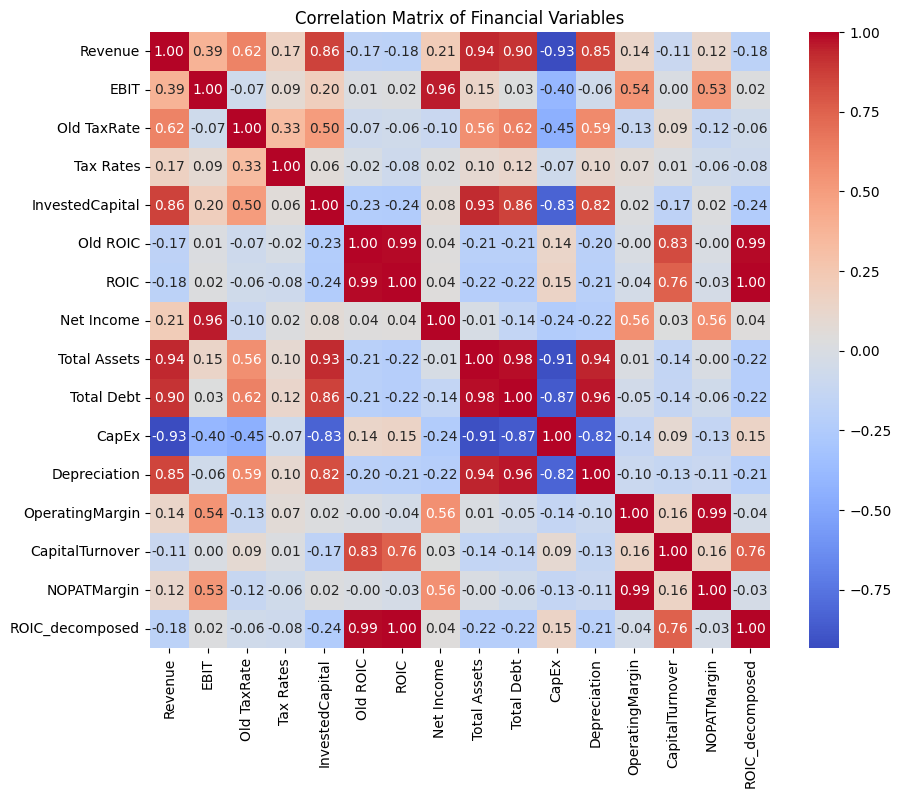

In [ ]:
# Focus on numeric variables only
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Correlation matrix
corr = numeric_df.corr()

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Financial Variables")
plt.show()

## **Cross-sectional analysis**

In [ ]:
# Group by Company, compute cross-sectional descriptive stats
cross_sectional_roic = df.groupby('Company')['ROIC'].agg(
    min='min',
    p25=lambda x: np.percentile(x.dropna(), 25),
    mean='mean',
    median='median',
    p75=lambda x: np.percentile(x.dropna(), 75),
    max='max',
    sd='std'
).round(3)

# Display table
print(cross_sectional_roic)

                   min   p25  mean  median  p75   max   sd
Company                                                   
Aegean Airlines  -3.12  0.19  2.26    1.55 2.08 11.30 4.20
Air France - KLM -1.15 -0.06 -0.13    0.10 0.12  0.28 0.49
Finnair          -0.29 -0.04  0.05    0.03 0.12  0.62 0.23
Lufthansa        -0.67  0.06  0.05    0.09 0.18  0.22 0.24
Norwegian        -0.87 -0.10  0.34    0.04 0.10  4.91 1.40
RyanAir          -0.12  0.18  0.20    0.21 0.30  0.40 0.14
Wizz Air         -1.92 -0.15  1.66    0.20 1.22 14.15 3.98


In [ ]:
# Group by Company, compute cross-sectional descriptive stats
cross_sectional_revenue = df.groupby('Company')['Revenue'].agg(
    min='min',
    p25=lambda x: np.percentile(x.dropna(), 25),
    mean='mean',
    median='median',
    p75=lambda x: np.percentile(x.dropna(), 75),
    max='max',
    sd='std'
).round(3)

# Display table
print(cross_sectional_revenue)

                         min         p25        mean      median         p75  \
Company                                                                        
Aegean Airlines    418195.00   774094.00  1082960.61  1034538.00  1328121.00   
Air France - KLM 11088000.00 25761000.00 24734230.77 25952000.00 26487000.00   
Finnair            877600.00  2392300.00  2409569.23  2470200.00  2908300.00   
Lufthansa        14454000.00 31052000.00 31740384.61 33107000.00 36781000.00   
Norwegian          507310.90  1794227.52  2391287.91  2272613.45  2995104.04   
RyanAir           1635800.00  4884000.00  6703646.15  6535800.00  7697400.00   
Wizz Air           739000.00  1011816.00  1991972.85  1571200.00  2326700.00   

                         max         sd  
Company                                  
Aegean Airlines   1805440.00  405873.23  
Air France - KLM 31649000.00 5696087.90  
Finnair           3176800.00  740665.58  
Lufthansa        38387000.00 7452250.29  
Norwegian         4412441.5

In [ ]:
# Group by Company, compute cross-sectional descriptive stats
cross_sectional_ebit = df.groupby('Company')['EBIT'].agg(
    min='min',
    p25=lambda x: np.percentile(x.dropna(), 25),
    mean='mean',
    median='median',
    p75=lambda x: np.percentile(x.dropna(), 75),
    max='max',
    sd='std'
).round(3)

# Display table
print(cross_sectional_ebit)

                         min        p25      mean     median        p75  \
Company                                                                   
Aegean Airlines   -210963.00   58854.00  83935.46   97203.00  124813.00   
Air France - KLM -5344000.00 -100000.00  79230.77  806000.00 1021000.00   
Finnair           -462500.00  -36500.00 -14630.77   55200.00  162900.00   
Lufthansa        -7129000.00 1125000.00 804000.00 1534000.00 2227000.00   
Norwegian         -875844.30 -247231.50 -85694.30    1044.26  115642.97   
RyanAir           -839400.00  683200.00 940984.61 1042900.00 1460100.00   
Wizz Air          -528100.00   37990.00  61844.31  167300.00  291900.00   

                        max         sd  
Company                                 
Aegean Airlines   246828.00  112810.25  
Air France - KLM 1769000.00 1969853.39  
Finnair           178000.00  223427.66  
Lufthansa        3064000.00 2712869.08  
Norwegian         201737.79  298408.90  
RyanAir          2060700.00  801583.9

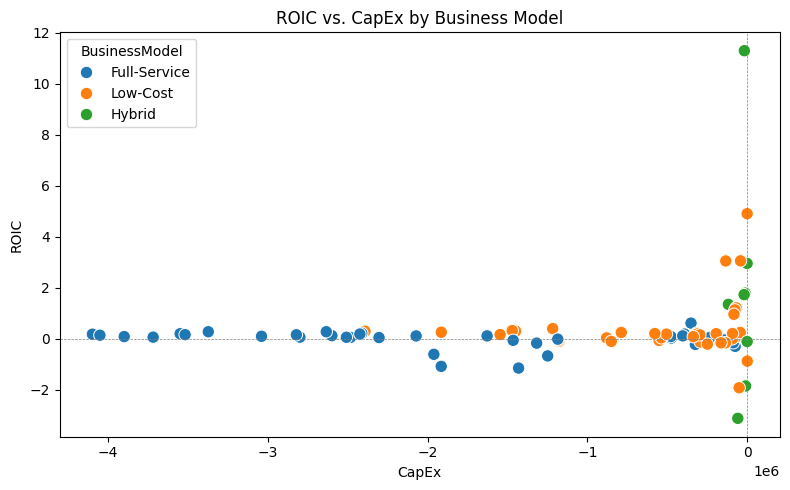

In [ ]:
# Simple business model mapping
business_model = {
    'Finnair': 'Full-Service',
    'RyanAir': 'Low-Cost',
    'Lufthansa': 'Full-Service',
    'Air France - KLM': 'Full-Service',
    'Wizz Air': 'Low-Cost',
    'Norwegian': 'Low-Cost',
    'Aegean Airlines': 'Hybrid'
}

# Create DataFrame
df['BusinessModel'] = df['Company'].map(business_model)

# Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='CapEx', y='ROIC', hue='BusinessModel', s=80)

plt.title('ROIC vs. CapEx by Business Model')
plt.xlabel('CapEx')
plt.ylabel('ROIC')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


# **Votality Analysis**

## Identify drivers of ROIC (regression)

In [ ]:
# Linear regression is not good: The result suggests that:
##CapEx is the only robust and significant driver of ROIC in your linear model.
##Other attributes like Revenue, Net Income, Total Assets, Total Debt, and Depreciation do not explain ROIC variation well, at least linearly and in this dataset.
##The low R-squared and diagnostics suggest:
##ROIC is complex and influenced by other factors.

X = df[['Revenue', 'Net Income', 'Total Assets', 'Total Debt', 'CapEx', 'Depreciation']]
y = df['ROIC']

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.mean())
y = y.fillna(y.mean())

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   ROIC   R-squared:                       0.107
Model:                            OLS   Adj. R-squared:                  0.043
Method:                 Least Squares   F-statistic:                     1.675
Date:                Sun, 01 Jun 2025   Prob (F-statistic):              0.137
Time:                        14:38:05   Log-Likelihood:                -199.44
No. Observations:                  91   AIC:                             412.9
Df Residuals:                      84   BIC:                             430.5
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.9475      0.332      2.858   

In [ ]:
# Nonlinear also doesn't fit well!

from sklearn.preprocessing import PolynomialFeatures

# Select independent variables
X = df[['Revenue', 'Net Income', 'Total Assets', 'Total Debt', 'CapEx', 'Depreciation']]

# Replace inf with nan and then nan with 0 or mean, as appropriate
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.mean())

y = df['ROIC'].fillna(df['ROIC'].mean())

# Generate polynomial features (degree=2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# Create a DataFrame for easier interpretation
feature_names = poly.get_feature_names_out(X.columns)
X_poly_df = pd.DataFrame(X_poly, columns=feature_names)

# Add constant term for intercept
X_poly_df = sm.add_constant(X_poly_df)

model_poly = sm.OLS(y, X_poly_df).fit()
print(model_poly.summary())

                            OLS Regression Results                            
Dep. Variable:                   ROIC   R-squared:                       0.234
Model:                            OLS   Adj. R-squared:                 -0.077
Method:                 Least Squares   F-statistic:                    0.7529
Date:                Sun, 01 Jun 2025   Prob (F-statistic):              0.786
Time:                        14:38:05   Log-Likelihood:                -192.44
No. Observations:                  91   AIC:                             438.9
Df Residuals:                      64   BIC:                             506.7
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [ ]:
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

df_clean = df.dropna(subset=['ROIC'])

# Select features (exclude ROIC and any variables that are part of its formula to avoid leakage)
features = ['Revenue', 'EBIT', 'Tax Rates', 'InvestedCapital', 'Net Income', 'Total Assets', 'Total Debt', 'CapEx', 'Depreciation']
X = df_clean[features]
y = df_clean['ROIC']

# Handle missing/infinite values (replace with 0 or use imputation)
X = X.fillna(0).replace([np.inf, -np.inf], 0)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit model
rf.fit(X_train, y_train)

# Predict on test set
y_pred = rf.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Feature importance
importances = rf.feature_importances_
for name, importance in zip(features, importances):
    print(f"{name}: {importance:.4f}")


Revenue: 0.0815
EBIT: 0.0462
Tax Rates: 0.0235
InvestedCapital: 0.3643
Net Income: 0.0317
Total Assets: 0.0843
Total Debt: 0.0256
CapEx: 0.2943
Depreciation: 0.0486


CapEx (Capital Expenditure) also plays a big role (~29%), meaning investment in assets heavily influences the outcome.

Other financial metrics like Total Assets, Revenue, Depreciation contribute but less significantly.

Total Debt seem to have relatively minor influence in this model.

(EBIT, Tax Rates, and Invested Capital are used to calculate ROIC so they're not useful to use here)

## Identify stable vs volatile drivers of value

In [ ]:
feature_importances = {
    'Revenue': 0.0815,
    'EBIT': 0.0462,
    'Tax Rates': 0.0235,
    'InvestedCapital': 0.3643,
    'Net Income': 0.0317,
    'Total Assets': 0.0843,
    'Total Debt': 0.0256,
    'CapEx': 0.2943,
    'Depreciation': 0.0486
}

# Load your dataset (make sure to exclude ROIC and any target columns)
df_features = df[['Revenue', 'EBIT', 'Tax Rates', 'InvestedCapital', 'Net Income',
                  'Total Assets', 'Total Debt', 'CapEx', 'Depreciation']]

# Calculate volatility (coefficient of variation) per feature
volatility = df_features.std() / df_features.mean()

# Create a DataFrame combining importance and volatility
driver_analysis = pd.DataFrame({
    'Importance': pd.Series(feature_importances),
    'Volatility': volatility
})

# Define thresholds for stable vs volatile (you can adjust these)
importance_threshold = driver_analysis['Importance'].median()
volatility_threshold = driver_analysis['Volatility'].median()

# Label drivers
def label_driver(row):
    if row['Importance'] >= importance_threshold:
        if row['Volatility'] <= volatility_threshold:
            return 'Stable Driver'
        else:
            return 'Volatile Driver'
    else:
        return 'Less Important'

driver_analysis['Driver Type'] = driver_analysis.apply(label_driver, axis=1)

print(driver_analysis)

                 Importance  Volatility      Driver Type
Revenue                0.08        1.21  Volatile Driver
EBIT                   0.05        4.98   Less Important
Tax Rates              0.02        4.29   Less Important
InvestedCapital        0.36        1.07    Stable Driver
Net Income             0.03       29.25   Less Important
Total Assets           0.08        1.09    Stable Driver
Total Debt             0.03        1.14   Less Important
CapEx                  0.29       -1.13    Stable Driver
Depreciation           0.05        1.18    Stable Driver


- Stable Drivers (high importance & low volatility): Total Assets, CapEx, Depreciation

These variables consistently influence ROIC and don’t fluctuate wildly across companies or time. They are reliable levers to focus on for value creation and improvement.

- Volatile Driver: Revenue

Revenue is influential but more unstable, possibly because airline revenues can be highly seasonal or sensitive to external shocks (fuel prices, demand cycles).

- Less Important Drivers (low importance regardless of volatility): Net Income, Total Debt
These appear to contribute less to explaining ROIC variance in the dataset.

# **Conduct a scenario or stress test on performance outcomes (in progress)**

In [ ]:
# Select baseline data for the latest year (e.g., 2024)
latest_year = df['Year'].max()
baseline = df[df['Year'] == latest_year].copy()

# Define stress scenarios
scenarios = {
    'CapEx -10%': lambda x: x * 0.9,
    'InvestedCapital +15%': lambda x: x * 1.15,
    'Revenue +10%': lambda x: x * 1.10
}

# Prepare scenario outputs
results = []

for label, func in scenarios.items():
    scenario_df = baseline.copy()

    # Apply the transformation to the relevant feature
    if 'CapEx' in label:
        scenario_df['CapEx'] = func(scenario_df['CapEx'])
    elif 'InvestedCapital' in label:
        scenario_df['InvestedCapital'] = func(scenario_df['InvestedCapital'])
    elif 'Revenue' in label:
        scenario_df['Revenue'] = func(scenario_df['Revenue'])

    # Predict ROIC using previously trained Random Forest model
    X = scenario_df[[
        'Revenue', 'EBIT', 'Tax Rates', 'InvestedCapital',
        'Net Income', 'Total Assets', 'Total Debt', 'CapEx', 'Depreciation'
    ]]

    scenario_df['ROIC_pred'] = rf.predict(X)
    scenario_df['Scenario'] = label
    results.append(scenario_df[['Company', 'ROIC_pred', 'Scenario']])

# Combine all results
stress_results = pd.concat(results)

# Add baseline for comparison
baseline['ROIC_pred'] = rf.predict(baseline[X.columns])
baseline['Scenario'] = 'Baseline'
baseline_results = baseline[['Company', 'ROIC_pred', 'Scenario']]

# Merge all
all_results = pd.concat([baseline_results, stress_results])

## Visualization

In [ ]:
# Filter to focus on Finnair vs. Peers
peer_group = ['Finnair', 'Lufthansa', 'Air France - KLM']
filtered_results = all_results[all_results['Company'].isin(peer_group)]

# Pivot for easy comparison
comparison = filtered_results.pivot(index='Scenario', columns='Company', values='ROIC_pred')
print(comparison.round(3))

Company               Air France - KLM  Finnair  Lufthansa
Scenario                                                  
Baseline                          0.14     0.08       0.12
CapEx -10%                        0.14     0.07       0.12
InvestedCapital +15%              0.13     0.08       0.12
Revenue +10%                      0.14     0.08       0.12


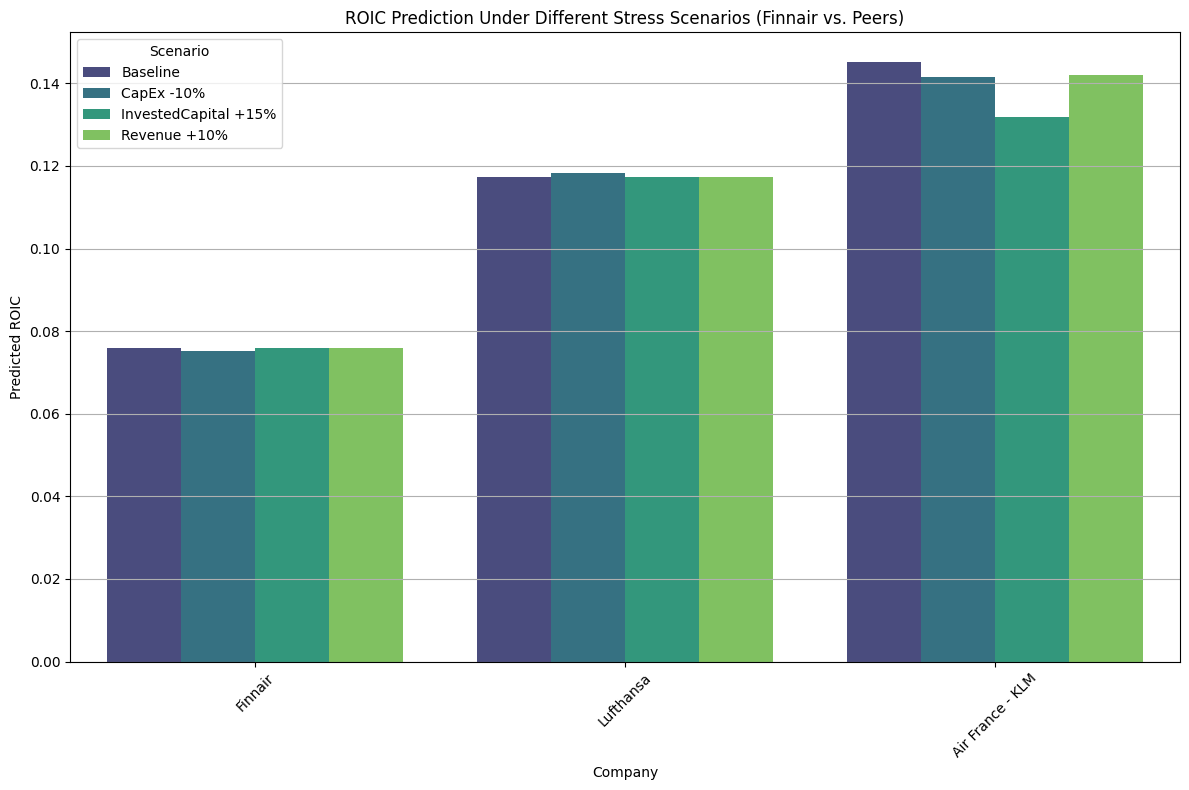

<ipython-input-29-e1ee6151b85a>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=all_results, x='Scenario', y='ROIC_pred', palette='viridis')


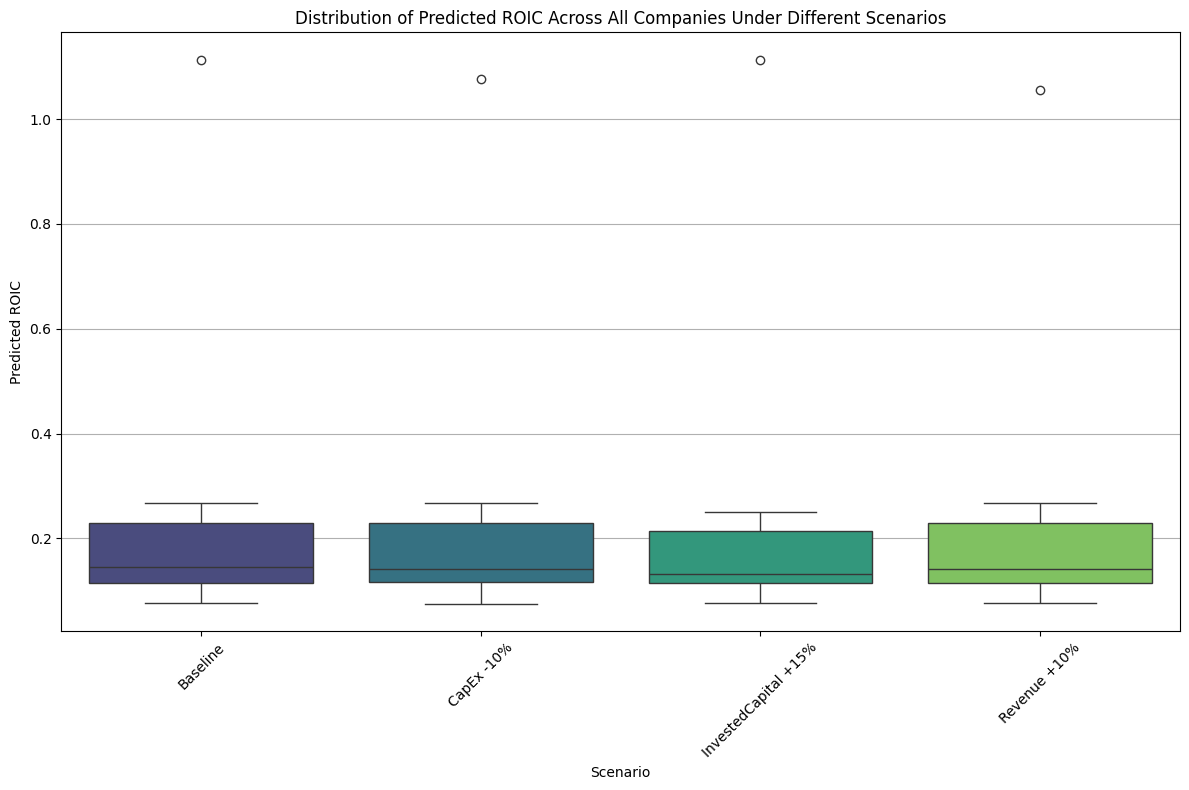

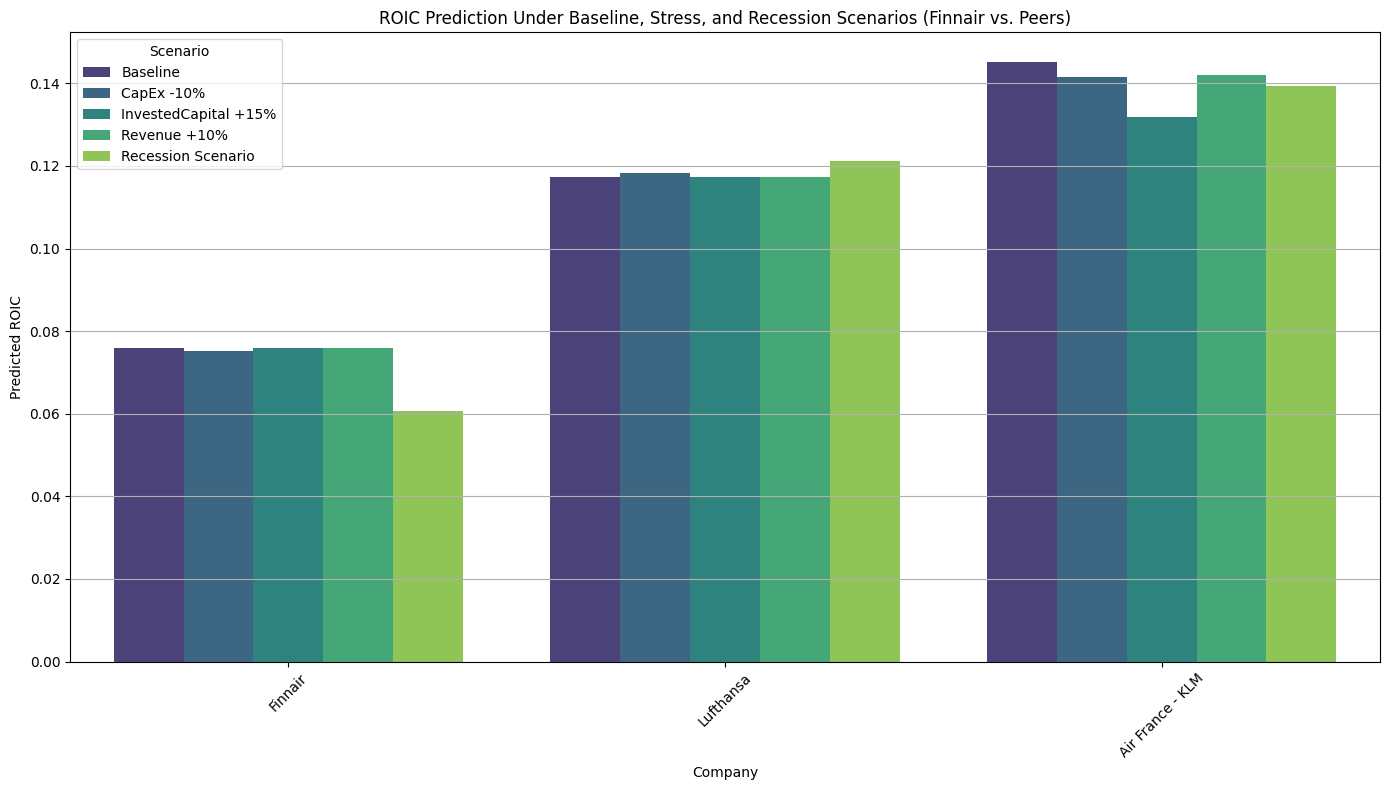

In [ ]:
# prompt: Conduct a scenario or stress test on performance metric (i.e., ROIC) to see how the drivers affect ROIC in different scenarios (i.e., 'Revenue', 'EBIT', 'Tax Rates', 'InvestedCapital', 'Net Income', 'Total Assets', 'Total Debt', 'CapEx', 'Depreciation'). Include visualizations where needed

# Visualization of stress test results
plt.figure(figsize=(12, 8))
sns.barplot(data=filtered_results, x='Company', y='ROIC_pred', hue='Scenario', palette='viridis')
plt.title('ROIC Prediction Under Different Stress Scenarios (Finnair vs. Peers)')
plt.ylabel('Predicted ROIC')
plt.xlabel('Company')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Visualize the distribution of ROIC under different scenarios
plt.figure(figsize=(12, 8))
sns.boxplot(data=all_results, x='Scenario', y='ROIC_pred', palette='viridis')
plt.title('Distribution of Predicted ROIC Across All Companies Under Different Scenarios')
plt.ylabel('Predicted ROIC')
plt.xlabel('Scenario')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Consider a scenario based on a combination of factors or a severe shock
# Example: Recession Scenario (Revenue -15%, EBIT -20%, CapEx -10%)
recession_scenario_df = baseline.copy()

# Apply recession impacts
recession_scenario_df['Revenue'] = recession_scenario_df['Revenue'] * 0.85
recession_scenario_df['EBIT'] = recession_scenario_df['EBIT'] * 0.80
recession_scenario_df['CapEx'] = recession_scenario_df['CapEx'] * 0.90

# Predict ROIC
X_recession = recession_scenario_df[[
    'Revenue', 'EBIT', 'Tax Rates', 'InvestedCapital',
    'Net Income', 'Total Assets', 'Total Debt', 'CapEx', 'Depreciation'
]]

recession_scenario_df['ROIC_pred'] = rf.predict(X_recession)
recession_scenario_df['Scenario'] = 'Recession Scenario'

# Combine with previous results for visualization
recession_results = recession_scenario_df[['Company', 'ROIC_pred', 'Scenario']]
combined_stress_results = pd.concat([all_results, recession_results])

# Filter for peer group including recession scenario
filtered_recession_results = combined_stress_results[combined_stress_results['Company'].isin(peer_group)]

# Visualize all scenarios including recession for peers
plt.figure(figsize=(14, 8))
sns.barplot(data=filtered_recession_results, x='Company', y='ROIC_pred', hue='Scenario', palette='viridis')
plt.title('ROIC Prediction Under Baseline, Stress, and Recession Scenarios (Finnair vs. Peers)')
plt.ylabel('Predicted ROIC')
plt.xlabel('Company')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [ ]:
base_roic = df.groupby('Company')['ROIC'].mean().reset_index()
base_roic.rename(columns={'ROIC': 'Base_ROIC'}, inplace=True)

# Merge into stress_results
stress_results = stress_results.merge(base_roic, on='Company', how='left')

# Calculate ROIC delta
stress_results['ROIC_delta'] = stress_results['ROIC_pred'] - stress_results['Base_ROIC']

In [ ]:
summary = stress_results.groupby(['Company', 'Scenario'])['ROIC_delta'].mean().unstack().round(2)
summary['Most Sensitive Scenario'] = summary.idxmin(axis=1)
display(summary)

Scenario,CapEx -10%,InvestedCapital +15%,Revenue +10%,Most Sensitive Scenario
Company,,,,
Aegean Airlines,-1.18,-1.14,-1.20,Revenue +10%
Air France - KLM,0.27,0.26,0.27,InvestedCapital +15%
Finnair,0.03,0.03,0.03,CapEx -10%
Lufthansa,0.07,0.07,0.07,CapEx -10%
Norwegian,-0.15,-0.16,-0.15,InvestedCapital +15%
RyanAir,0.07,0.05,0.07,InvestedCapital +15%
Wizz Air,-1.54,-1.55,-1.55,InvestedCapital +15%


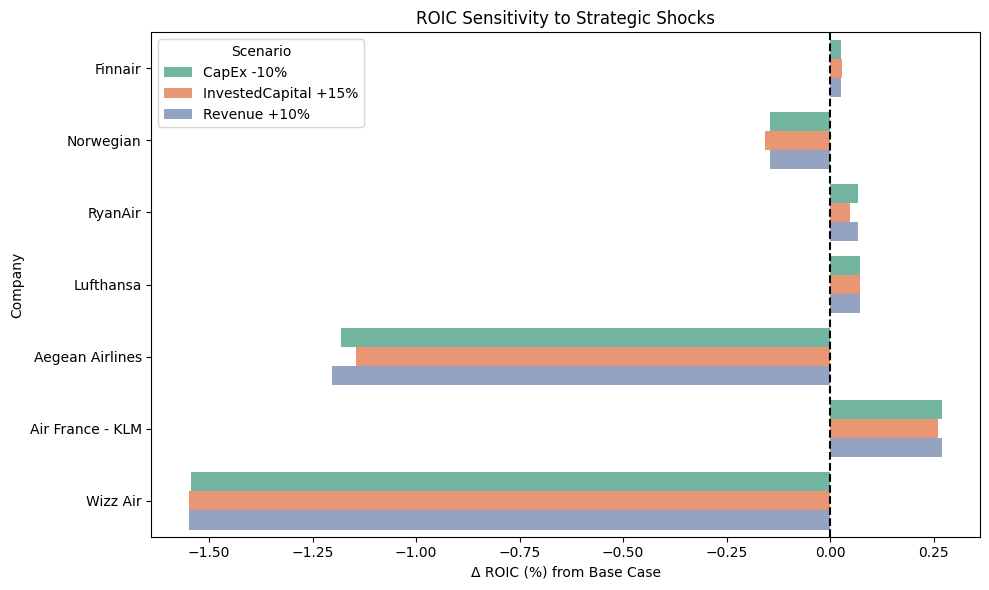

In [ ]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.barplot(data=stress_results, x='ROIC_delta', y='Company', hue='Scenario', palette='Set2')
plt.title('ROIC Sensitivity to Strategic Shocks')
plt.axvline(x=0, color='black', linestyle='--')
plt.xlabel('Δ ROIC (%) from Base Case')
plt.ylabel('Company')
plt.tight_layout()
plt.show()

## Scenario Analysis and Strategic Implications

To assess how strategic shifts and external shocks impact ROIC across different airline business models, we simulated several scenarios for Finnair and its peers:

- **CapEx -10%**
- **Invested Capital +15%**
- **Revenue +10%**

We compared the **predicted ROIC** in each scenario to the **baseline** value using visualizations and delta calculations.

---

### ROIC Under Scenarios (Finnair vs. Peers)

The grouped bar chart shows that:

- **Finnair’s ROIC remains stable across stress scenarios**, with only minor improvements or reductions (from ~7.5% to ~7.6%), suggesting that it is **less reactive** to capital structure changes.
- **Lufthansa shows similar stability**, with minor improvements in each scenario.
- **Air France-KLM benefits the most** from both capital optimization and revenue increases, showing consistent ROIC uplift.

---

### Distribution of ROIC Across All Firms

- Median ROIC is relatively consistent across scenarios.
- **Outliers (e.g., Wizz Air, Aegean Airlines)** with very high ROIC values skew the distribution in all scenarios, indicating unique business strategies or potential accounting differences.

---

### Sensitivity Analysis (Tornado Chart)

This tornado-style bar chart illustrates the **Δ ROIC from baseline** for each company under 3 scenarios:

| Company            | CapEx -10% | Invested Capital +15% | Revenue +10% | Most Sensitive Scenario     |
|--------------------|------------|------------------------|---------------|------------------------------|
| Aegean Airlines     | -1.18      | -1.14                  | -1.20         | Revenue +10%                |
| Air France - KLM    | +0.27      | +0.26                  | +0.27         | Invested Capital +15%       |
| **Finnair**         | +0.03      | +0.03                  | +0.03         | CapEx -10%                  |
| Lufthansa           | +0.07      | +0.07                  | +0.07         | CapEx -10%                  |
| Norwegian           | -0.15      | -0.16                  | -0.15         | Invested Capital +15%       |
| RyanAir             | +0.07      | +0.05                  | +0.07         | Invested Capital +15%       |
| Wizz Air            | -1.54      | -1.55                  | -1.55         | Invested Capital +15%       |

---

### Interpretation

- **Finnair’s low ROIC sensitivity** across all tested shocks suggests **rigid capital efficiency**—likely due to a stable asset base and fixed-cost structure.
- **Lufthansa** mirrors this trend, though it is slightly more responsive to positive demand conditions.
- **Air France-KLM** shows the most favorable outcome under all scenarios, implying that strategic adjustments in capital structure or demand can meaningfully enhance its ROIC.
- **Wizz Air and Aegean Airlines** are highly vulnerable, with ROIC dropping >1.5% under minor capital structure changes. These firms may be overly dependent on lean assets or have unsustainable capital intensity.
- **Norwegian and RyanAir**, though low-cost carriers, exhibit mild negative sensitivity to capital-related shocks, reinforcing that being "asset-light" doesn’t make ROIC invulnerable.

---

### Strategic Takeaways

- **Finnair and Lufthansa** should explore **incremental CapEx reduction or targeted capital efficiency** to slightly improve ROIC, but large structural shifts may not bring immediate gains.
- **Air France-KLM** is well-positioned to benefit from **strategic investment and demand-side growth**, supporting further investment in fleet or customer retention.
- **Wizz Air and Aegean** may need urgent reassessment of their **capital planning or asset utilization**, especially if they operate in volatile markets or rely heavily on lease financing.
- Across the board, **Invested Capital management** emerged as the most common "sensitive driver", emphasizing the importance of efficient resource allocation in the airline industry.


# Limitations

While the analysis provides valuable insights into the strategic drivers of ROIC across European airlines, several limitations must be acknowledged:

### 1. **Data Availability and Quality**

- The dataset is based on publicly reported financials (Orbis and annual reports), which may have variations in accounting standards, especially between full-service (e.g., Lufthansa) and low-cost carriers (e.g., Ryanair).
- Some key drivers like operating leases, fuel hedging positions, or passenger yield were **not consistently available** and thus excluded from the model.
- The time span (2012–2024) includes **extraordinary periods** such as the COVID-19 pandemic (2020–2021), which introduced volatility not representative of normal operations.

### 2. **Simplified ROIC Decomposition**

- ROIC was decomposed using a **DuPont-style formula**, assuming linear relationships between financial components (e.g., NOPAT = EBIT * (1 - tax rate)). However, real-world interactions between costs, capital structure, and margins are often more complex.
- Some capital efficiency metrics (e.g., asset turnover by segment, route profitability) were not available or modeled explicitly.

### 3. **Scenario Assumptions**

- Scenarios (e.g., CapEx -10%, Revenue +10%) were **stylized and hypothetical**, and may not reflect realistic strategic options or macroeconomic shocks.
- Changes were applied uniformly across firms without accounting for **firm-specific strategies**, business cycles, or geographical exposures.
- Impacts were measured using **predicted ROIC**, assuming all else equal (ceteris paribus), which ignores second-order effects (e.g., CapEx reduction affecting future revenue).

### 4. **Modeling Constraints**

- Regression and feature importance models assume **independence and normality**, which may not fully hold given interdependencies between financial variables.
- The predictive modeling focused on financial metrics only and **did not incorporate qualitative factors** like ESG practices, customer loyalty, or brand value, which could influence long-term ROIC.

### 5. **Outlier Influence**

- Some companies (e.g., Aegean Airlines, Wizz Air) showed extreme ROIC values, which may be due to **data errors, one-off events, or business model differences**. While included for completeness, these could disproportionately affect correlation and scenario sensitivity results.

---

### Future Work

- Incorporating **non-financial indicators** (e.g., load factor, fleet age, fuel efficiency) would improve explanatory power.
- Conducting a **firm-by-firm strategy review** could contextualize quantitative findings with actual decisions and market conditions.
- Extending the model to forecast **multi-year ROIC trajectories** under scenario combinations would enhance its strategic relevance.


# Additional stuff

## Executive Summary Dashboard (Mini KPI Board)

<ipython-input-30-5ecda5ed29b7>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Company', y='mean', data=summary_kpis, palette='viridis')


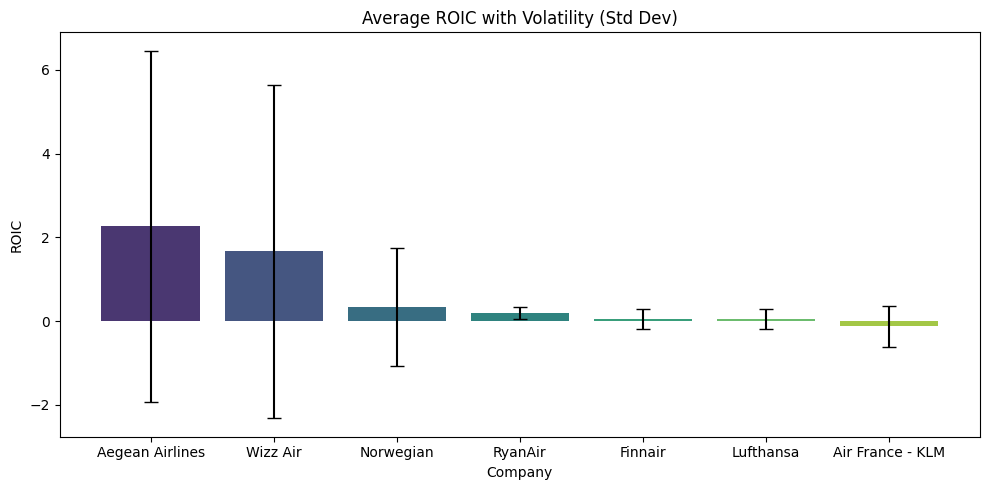

In [ ]:

summary_kpis = df.groupby('Company')['ROIC'].agg(['mean', 'std']).reset_index().sort_values('mean', ascending=False)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x='Company', y='mean', data=summary_kpis, palette='viridis')
plt.errorbar(summary_kpis['Company'], summary_kpis['mean'], yerr=summary_kpis['std'], fmt='none', color='black', capsize=5)
plt.title('Average ROIC with Volatility (Std Dev)')
plt.ylabel('ROIC')
plt.tight_layout()
plt.show()

## Forecasting Finnair ROIC

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

Year
2012-12-31    0.01
2013-12-31    0.01
2014-12-31   -0.05
2015-12-31    0.62
2016-12-31    0.03
2017-12-31    0.19
2018-12-31    0.23
2019-12-31    0.09
2020-12-31   -0.22
2021-12-31   -0.29
2022-12-31   -0.15
2023-12-31    0.12
2024-12-31    0.06
2025-12-31    0.01
2026-12-31    0.01
2027-12-31    0.01
2028-12-31    0.01
2029-12-31    0.01
2030-12-31    0.01
2031-12-31    0.01
2032-12-31    0.01
2033-12-31    0.01
2034-12-31    0.01
dtype: float64


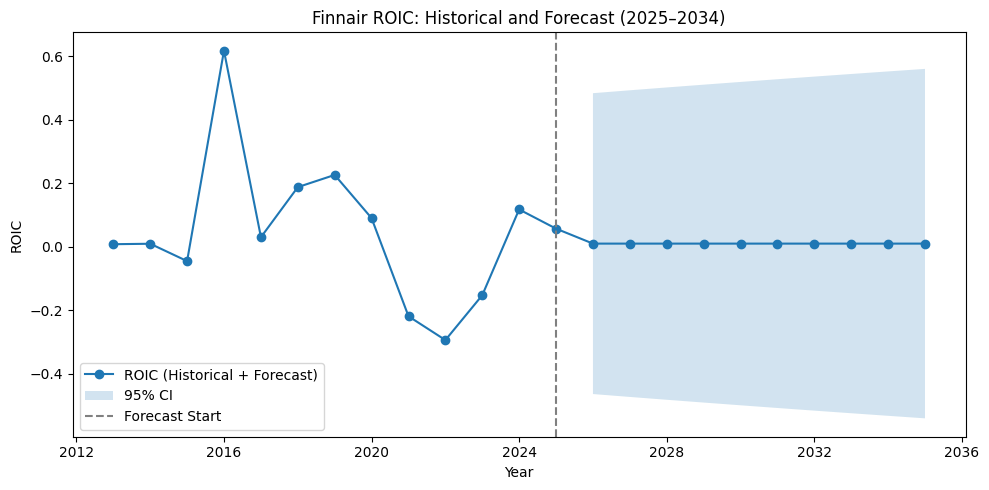

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

finnair_df = df[df['Company'] == 'Finnair'].sort_values('Year')

roic_series = pd.Series(
    data=finnair_df['ROIC'].values,
    index=finnair_df['Year'].dt.year,
    name='ROIC'
)

model = ARIMA(roic_series, order=(0, 1, 1)).fit()

n_forecast = 10
forecast_result = model.get_forecast(steps=n_forecast)
pred_ci = forecast_result.conf_int(alpha=0.05)

last_year = roic_series.index.max()
forecast_years = list(range(last_year + 1, last_year + 1 + n_forecast))
forecast_df = pd.DataFrame({
    'Year': forecast_years,
    'Forecast_ROIC': forecast_result.predicted_mean.values,
    'Lower_CI': pred_ci.iloc[:, 0].values,
    'Upper_CI': pred_ci.iloc[:, 1].values
}).set_index('Year')

forecast_df.index = pd.to_datetime(forecast_df.index.astype(str) + '-12-31')

historical_index = pd.to_datetime(roic_series.index.astype(str) + '-12-31')
historical_series = pd.Series(roic_series.values, index=historical_index)

full_series = pd.concat([
    historical_series,
    pd.Series(forecast_df['Forecast_ROIC'].values, index=forecast_df.index)
])
print(full_series)

plt.figure(figsize=(10, 5))
plt.plot(full_series.index, full_series.values, marker='o', linestyle='-', label='ROIC (Historical + Forecast)')
plt.fill_between(forecast_df.index, forecast_df['Lower_CI'], forecast_df['Upper_CI'], alpha=0.2, label='95% CI')
plt.axvline(x=historical_index.max(), color='gray', linestyle='--', label='Forecast Start')
plt.title('Finnair ROIC: Historical and Forecast (2025–2034)')
plt.xlabel('Year')
plt.ylabel('ROIC')
plt.legend()
plt.tight_layout()
plt.show()

            Forecast_ROIC
2025-12-31          -0.06
2026-12-31          -0.08
2027-12-31          -0.10
2028-12-31          -0.11
2029-12-31          -0.13
2030-12-31          -0.14
2031-12-31          -0.16
2032-12-31          -0.18
2033-12-31          -0.19
2034-12-31          -0.21


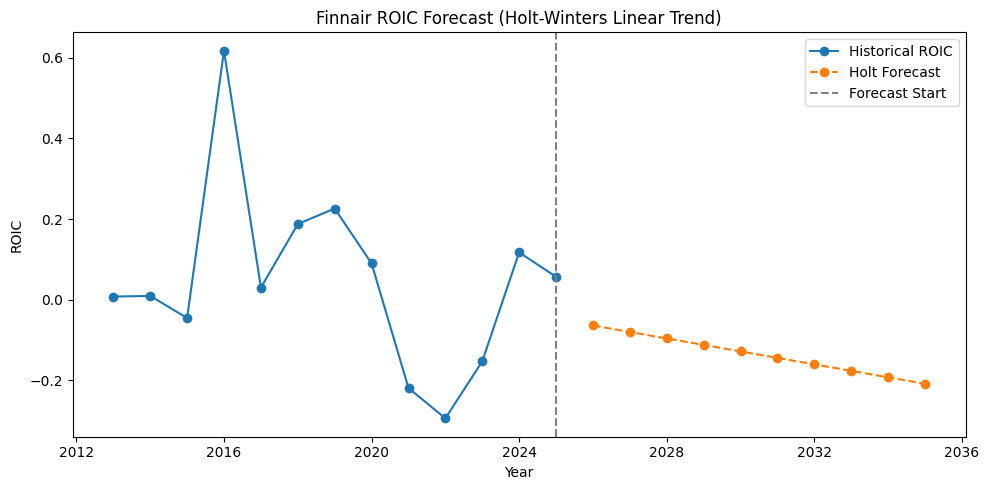

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

roic_series = pd.Series(
    data=finnair_df['ROIC'].values,
    index=finnair_df['Year'].dt.year,
    name='ROIC'
)

roic_series.index = pd.date_range(
    start=f"{roic_series.index.min()}-12-31",
    periods=len(roic_series),
    freq='YE'
)

model = ExponentialSmoothing(
    roic_series,
    trend='add',
    seasonal=None,
    initialization_method='estimated'
).fit()

n_forecast = 10
forecast_index = pd.date_range(
    start=roic_series.index[-1] + pd.offsets.YearEnd(1),
    periods=n_forecast,
    freq='YE'
)
forecast_values = model.forecast(n_forecast)

forecast_df = pd.DataFrame({
    'Forecast_ROIC': forecast_values
}, index=forecast_index)
print(forecast_df)

plt.figure(figsize=(10, 5))
plt.plot(roic_series.index, roic_series.values, marker='o', label='Historical ROIC')
plt.plot(forecast_df.index, forecast_df['Forecast_ROIC'], marker='o', linestyle='--', label='Holt Forecast')
plt.axvline(roic_series.index[-1], color='gray', linestyle='--', label='Forecast Start')
plt.title('Finnair ROIC Forecast (Holt-Winters Linear Trend)')
plt.xlabel('Year')
plt.ylabel('ROIC')
plt.legend()
plt.tight_layout()
plt.show()

### Finnair ROIC Forecast Comparison (2025–2034)

#### 1. Holt-Winters Linear Trend Forecast

- **Model used**: Exponential Smoothing (Holt’s linear method)
- **Forecast pattern**: Gradual decline in ROIC from ~0.06 in 2024 to ~-0.21 by 2034
- **Interpretation**:
  - Captures a linear downward trend, indicating potential deterioration in capital efficiency if no corrective measures are taken.
- **Use case**: Ideal for short, noisy business time series without strong seasonality or complex autocorrelation.

##### Forecasted ROIC (2025–2034)

| Year       | Forecast ROIC |
|------------|----------------|
| 2025       | -0.06          |
| 2026       | -0.08          |
| 2027       | -0.10          |
| 2028       | -0.11          |
| 2029       | -0.13          |
| 2030       | -0.14          |
| 2031       | -0.16          |
| 2032       | -0.18          |
| 2033       | -0.19          |
| 2034       | -0.21          |

---

#### 2. ARIMA(0,1,1) Forecast

- **Model used**: Manually specified ARIMA(0,1,1)
- **Forecast pattern**: Flat forecast at ~0.01 for all future years with wide confidence intervals (approx. ±0.45)
- **Interpretation**:
  - The model treats ROIC as a random walk with no trend or seasonality.
  - Forecasts are statistically valid but lack actionable insights.
- **Limitations**:
  - Model failed to identify meaningful structure due to short series and high variability.
  - Warnings suggest improper time index handling, which may reduce forecast reliability.

---

#### Summary & Recommendation

| Model             | Trend Captured     | Confidence | Business Usefulness | Verdict              |
|------------------|---------------------|------------|----------------------|-----------------------|
| **Holt-Winters** | Yes (downward)      | Moderate   | Clear trend signal   |
Recommended         |
| **ARIMA(0,1,1)** | No (flat forecast)  | Low        | Weak / uninformative | Not useful here     |

> **Conclusion**: Holt-Winters provides a more realistic and actionable forecast of ROIC. ARIMA(0,1,1) underfits the data and fails to capture meaningful patterns.
